In [1]:
import scanpy as sc
import drug2cell as d2c
import blitzgsea as blitz
import pandas as pd

sc.settings.set_figure_params(dpi=80)

In [ ]:
vics = sc.read_h5ad("./vics_export_drug2cell.h5ad")
vics.X = vics.layers["counts"]
vics.raw = vics.copy()
d2c.score(vics, use_raw=True)

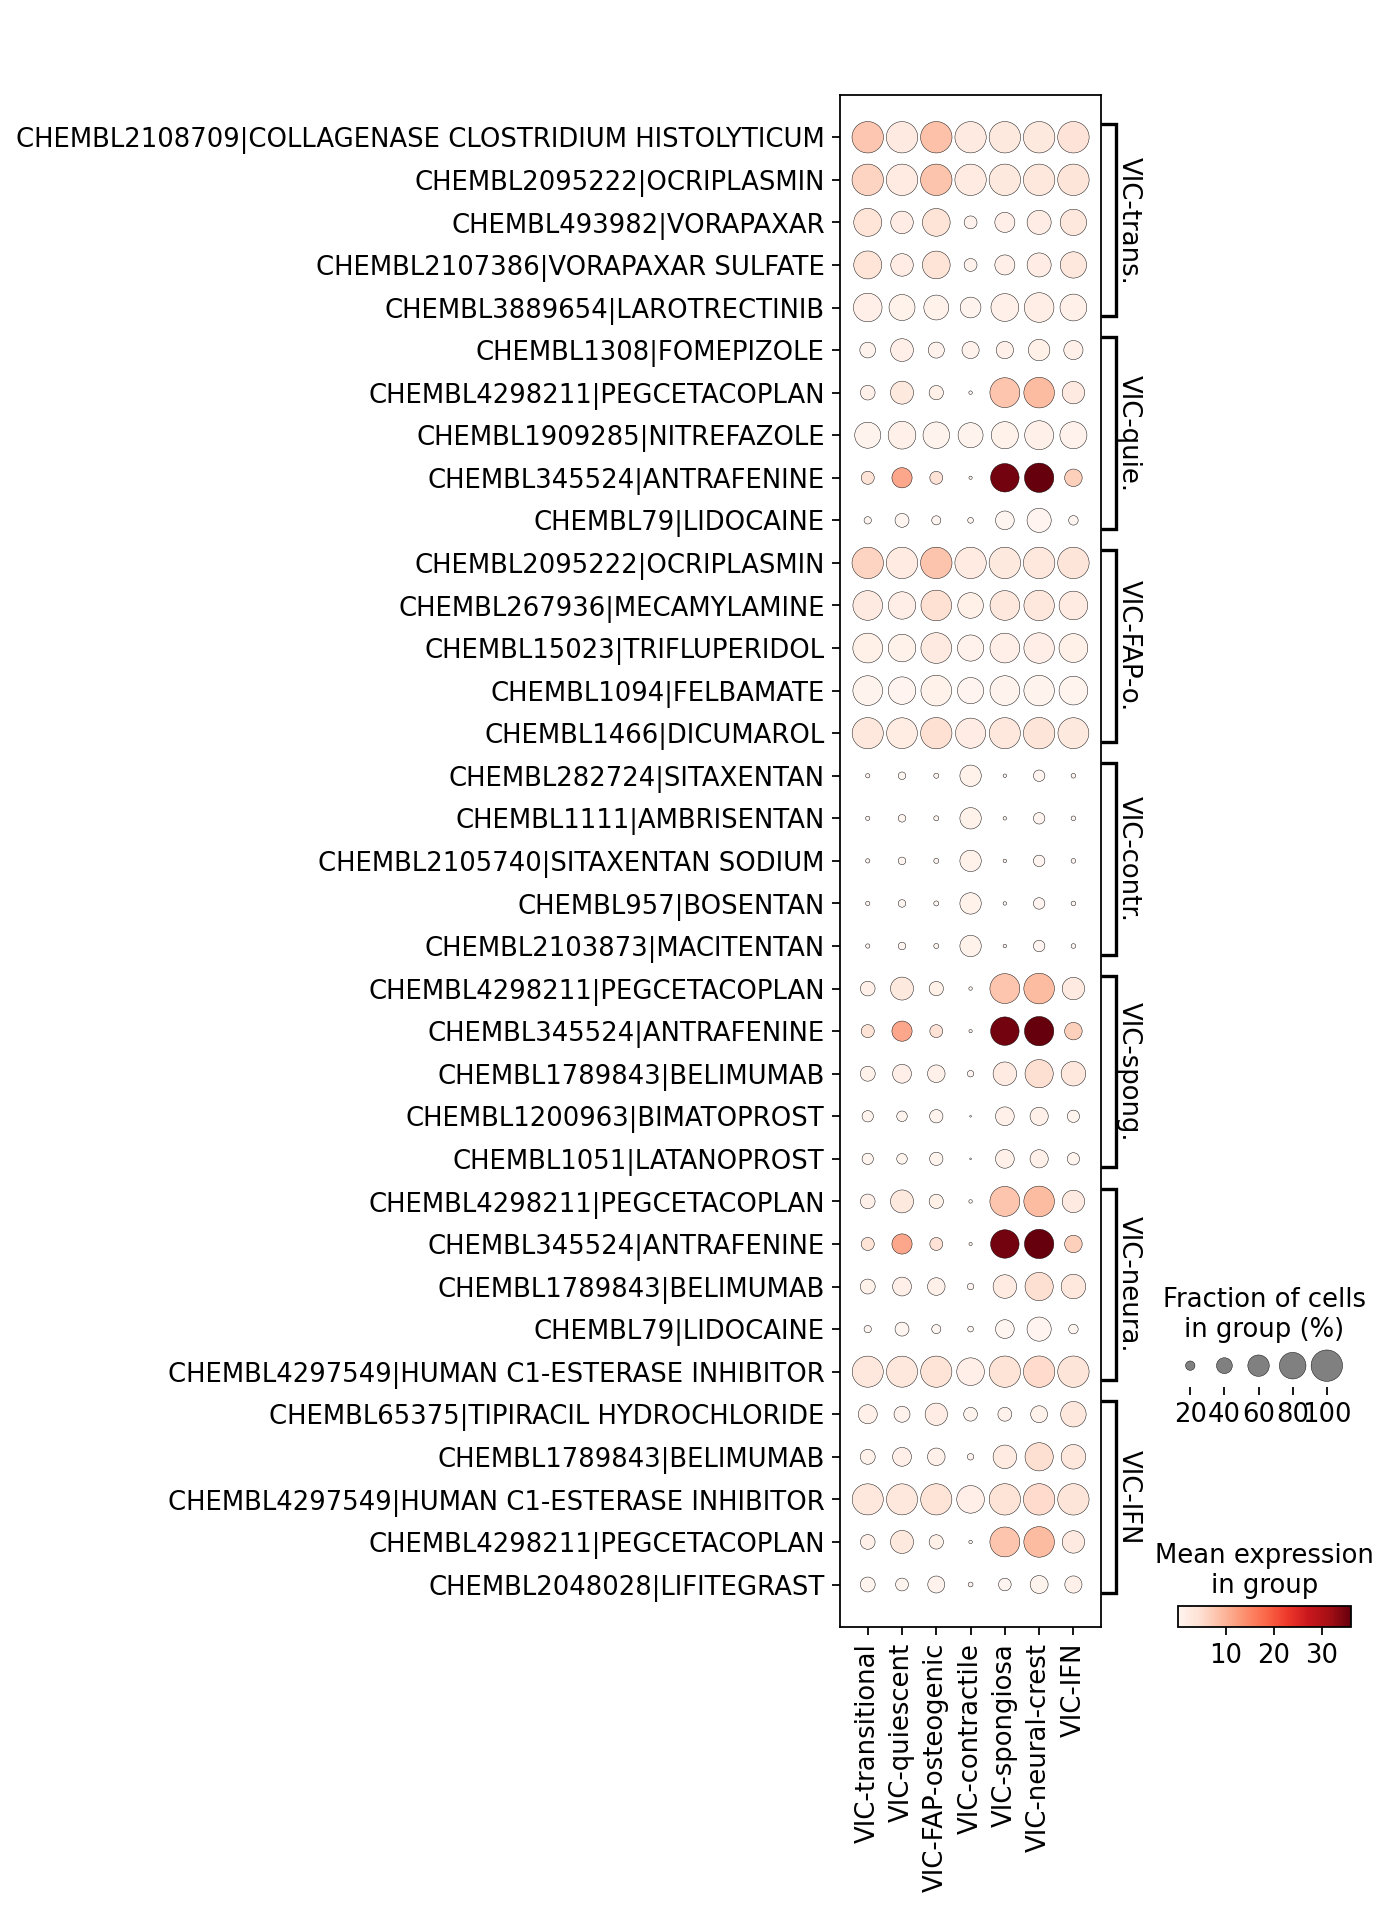

In [3]:
vics.obs['annotations_level2_readable'] = pd.Categorical(vics.obs['annotations_level2_readable'])
sc.tl.rank_genes_groups(vics.uns['drug2cell'], method="wilcoxon", groupby="annotations_level2_readable")
sc.pl.rank_genes_groups_dotplot(vics.uns['drug2cell'], swap_axes=True, dendrogram=False, n_genes=5)

In [4]:
de_df = sc.get.rank_genes_groups_df(
    vics.uns['drug2cell'],
    group=None  # all groups
)

In [ ]:
vics.uns['drug2cell'].write('./drug2cell_output.h5ad')
de_df.to_csv("./drug2cell_DE_results.csv", index=False)